# **IBL brain-wide map dataset**

## **Overview**

### **The brain-wide map dataset**

The International Brain Laboratory (IBL) Brainwide Map project set out to map neural activity across the entire mouse brain at single-spike, cellular resolution during a standardized decision-making task. The resulting dataset has been made publicly available.

The dataset includes:


* Data collected across **12 laboratories**

* Recordings from **139 mice**

* A total of **459 behavioral sessions**

* **699 Neuropixels probe insertions**

* Coverage of **281 brain regions**

* **621,733 recorded neurons**, including

* **75,708 good neurons**


![](https://ibl-brain-wide-map-public.s3.us-east-1.amazonaws.com/sample_data/Neuromatch/figures/bwm_recordings.png)



### **Recording Plan**

Neural activity was recorded using Neuropixels probes, targeted according to a standardized grid system with insertion sites spaced 500 µm apart.

The recording system aimed to:
* Achieve uniform coverage across the brain

* Prioritize regions with known anatomical connectivity (e.g., the cerebellum and medulla were sampled from the right hemisphere)

* Replicate each recording site in at least two independent laboratories

* Evaluate the reproducibility of neural activity across subjects and experimental sites (via the "repeated site")

* Investigate bilateral and interhemispheric interactions (via the "bilateral sites")

![](https://ibl-brain-wide-map-public.s3.us-east-1.amazonaws.com/sample_data/Neuromatch/figures/bwm_plan.png)


### **Decision making task**

In the IBL decision making task a visual stimulus appears at the edge of the screen and mice must bring the stimulus to the screen centre by moving a wheel with their front two paws. If they successfully bring the stimulus to the screen centre, they receive a reward of sugar water ; if however they move the wheel in the wrong direction until the stimulus reaches beyond the screen edge, a white noise tone is played. To initiate a trial, the mouse must hold the wheel still for a continuous period between 0.4-0.7s ; they are then alerted of the start of the trial by the simultaneous presentation of the stimulus on the screen and a go cue tone. Mice have a maximum of 60s to make a decision before the trial times out and a white noise tone is played.

Varying contrasts of visual stimulus are shown throughout the session (100%, 25%, 12.5%, 6.25% and 0%). The probability of the stimulus appearing on the left or the right changes between blocks of trials. During 0% contrast trials (where no stimulus appears on the screen but a wheel response is required), the mice can use the inferred block structure to guide their decision.


![](https://ibl-brain-wide-map-public.s3.us-east-1.amazonaws.com/sample_data/Neuromatch/figures/task.png)


### **Accessing the data**
For the purposes of this course, we have precomputed task-aligned peri-stimulus time histograms (PSTHs) for all good clusters in the dataset. This allows you to quickly begin working with the data using a simplified and accessible format. The tutorial below is based on this preprocessed data.

To access the full dataset, including raw electrophysiology (action potential and LFP bands), spike sorting output, wheel movement, video recordings, and pose estimation data please refer to this [this introductary notebook](https://colab.research.google.com/drive/1_1qfa-DLDbezyFXguFOnJJWF5aJ5AH0i#scrollTo=-TJR7XEgtBxS) and [this tutorial](https://colab.research.google.com/drive/1y3sRI1wC7qbWqN6skvulzPOp6xw8tLm7#scrollTo=hRZA78AoaBIC).



> *All data are made available under the CC BY 4.0 license.*

## **1. Installation and setup**

The code blocks in this section install and import required packages. We also define a set of utility functions that will be used to download and load data throughout the rest of the tutorial. **Make sure these cells are run before continuing onto the next sections.**

### **Install dependencies**

In [ ]:
! pip install ONE-api --quiet
! pip install ibllib --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 16.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.0/140.0 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.5/11.5 MB 28.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.4/15.4 MB 26.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.1/90.1 kB 1.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.4/48.4 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 68.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.9/57.9 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 442.6/442.6 kB 27.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 102.6/102.6 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.0/48.0 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.0/211.0

### **Setup ONE**

In [ ]:
# When running in jupyter set number of threads to 1
import os
os.environ.setdefault('ONE_HTTP_DL_THREADS', '1')

from one.api import ONE
ONE.setup(base_url='https://openalyx.internationalbrainlab.org', silent=True)
one = ONE(password='international')

Connected to https://openalyx.internationalbrainlab.org as user "intbrainlab"


### **Define imports**

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import pandas as pd
from scipy import sparse
import numpy as np
from one.remote.aws import s3_download_file
import zipfile
import tqdm
import scipy.stats as stats
from iblutil.util import Bunch
from scipy.ndimage import gaussian_filter1d

from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

# This is to view dataframe interactively in Google colab
if 'google.colab' in sys.modules:
    from google.colab import data_table
    data_table.enable_dataframe_formatter()

# This is to style figures
if sys.version_info >= (3, 10):
    from ibl_style.style import figure_style
    figure_style()

### **Define loading utility functions**

In [ ]:
def download_data(event):
  assert event in ['firstMove', 'stimOn', 'feedback'], 'event must be one of "firstMove", "stimOn" or "feedback'

  # Dataset name
  fname = f'data_{event}.zip'
  # Remote location of data
  s3_data_path = f'sample_data/Neuromatch/{fname}'
  # Local location to download data to
  save_path = one.cache_dir.joinpath('Neuromatch', fname)
  save_path.parent.mkdir(exist_ok=True, parents=True)

  # Download file
  file = s3_download_file(s3_data_path, save_path)
  # Unzip content
  with zipfile.ZipFile(file, 'r') as zip_ref:
    zip_ref.extractall(save_path.parent)


def get_data_path(event):

  return one.cache_dir.joinpath('Neuromatch', f'data_{event}')


def load_metadata(event):
  metadata = Bunch()
  data_path = get_data_path(event)
  metadata['clusters'] = pd.read_parquet(data_path.joinpath('clusters.pqt'))
  metadata['trials'] = pd.read_parquet(data_path.joinpath('trials.pqt'))
  metadata['sessions'] = pd.read_parquet(data_path.joinpath('sessions.pqt'))
  metadata['times'] = np.load(data_path.joinpath('t.npy'))
  metadata['nbins'] = metadata['times'].size
  metadata['dt'] = np.round(np.median(np.diff(metadata['times'])), 2)
  metadata['data_path'] = data_path

  return metadata


def load_times(data_path):
  return np.load(data_path.joinpath('t.npy'))


def load_psth(data_path, pid, nbins=150):
    psth = sparse.load_npz(data_path.joinpath(f'{pid}.npz')).toarray()
    psth = psth.reshape(psth.shape[0], -1, nbins)
    return psth

### **Define processing utility functions** <a name="Utility-functions"></a>

In [ ]:
def split_trials_by_variable(trials, split='contrast'):
  trials = trials.set_index('psth_index')
  if split == 'contrast':
    trials['contrast'] = np.nansum([trials['contrastLeft'], trials['contrastRight']], axis=0) * 100
    grp = trials.groupby('contrast')
  elif split == 'signed contrast':
    trials['signedContrast'] = np.nansum([-1 * trials['contrastLeft'], trials['contrastRight']], axis=0) * 100
    grp = trials.groupby('signedContrast')
  elif split == 'stimulus':
    trials['stimulus'] = 'right'
    trials.loc[trials['contrastRight'].isna(), 'stimulus'] = 'left'
    grp = trials.groupby('stimulus')
  elif split == 'choice':
    grp = trials.groupby('choice')
  elif split == 'block':
    grp = trials.groupby('probabilityLeft')
  else:
    raise NotImplementedError('split must be one of "contrast", "signed contrast", "stimulus", "choice" or "block"')

  return grp.groups


def get_avg_psth_for_insertion(pid, meta, reg=None, uuids=None, split=None):

  df = meta.clusters[meta.clusters['pid'] == pid]
  df = df[['acronym', 'pid', 'uuids', 'cluster_id', 'psth_index']]
  sp = load_psth(meta.data_path, pid, nbins=meta.nbins)

  if reg is not None:
    in_reg = df['acronym'] == reg
    sp = sp[:, in_reg.values, :]
    df = df[in_reg].reset_index(drop=True)

  if uuids is not None:
    in_uuid = df['uuids'].isin(uuids)
    sp = sp[:, in_uuid.values, :]
    df = df[in_uuid].reset_index(drop=True)

  if split is None:
    psth = sp.mean(axis=0) / meta['dt']
  else:
    psth = dict()
    eid = meta.sessions[meta.sessions['pid'] == pid].iloc[0]['eid']
    trials = meta.trials[meta.trials['eid'] == eid].reset_index(drop=True)
    grps = split_trials_by_variable(trials, split=split)

    for key, vals in grps.items():
      psth[key] = sp[vals, :, :].mean(axis=0)

  return psth, df

def get_avg_psth_for_region(reg, meta, split=None):
  clusters = meta.clusters[meta.clusters['acronym'] == reg]
  pids = clusters['pid'].unique()
  all_df = []
  all_psth = []
  for pid in pids:
    psth, df = get_avg_psth_for_insertion(pid, meta, reg=reg, split=split)
    all_df.append(df)
    all_psth.append(psth)

  all_df = pd.concat(all_df).reset_index(drop=True)
  if split is None:
    all_psth = np.concatenate(all_psth)
  else:
    all_psth = {key: np.concatenate([d[key] for d in all_psth if key in d.keys()])
    for key in all_psth[0]}


  return all_psth, all_df


def get_avg_psth_for_clusters(uuids, meta, split=None):
  clusters = meta.clusters[meta.clusters['uuids'].isin(uuids)]
  pids = clusters['pid'].unique()
  all_df = []
  all_psth = []
  for pid in pids:
    psth, df = get_avg_psth_for_insertion(pid, meta, uuids=uuids, split=split)
    all_df.append(df)
    all_psth.append(psth)

  all_df = pd.concat(all_df).reset_index(drop=True)
  if split is None:
    all_psth = np.concatenate(all_psth)
  else:
    all_psth = {key: np.concatenate([d[key] for d in all_psth if key in d.keys()])
    for key in all_psth[0]}

  return all_psth, all_df



def get_psth_for_insertion(pid, meta, reg=None, uuids=None):

  df = meta.clusters[meta.clusters['pid'] == pid]
  df = df[['acronym', 'pid', 'uuids', 'cluster_id', 'psth_index']]
  sp = load_psth(meta.data_path, pid, nbins=meta.nbins)

  if reg is not None:
    in_reg = df['acronym'] == reg
    sp = sp[:, in_reg.values, :]
    df = df[in_reg].reset_index(drop=True)

  if uuids is not None:
    in_uuid = df['uuids'].isin(uuids)
    sp = sp[:, in_uuid.values, :]
    df = df[in_uuid].reset_index(drop=True)


  eid = meta.sessions[meta.sessions['pid'] == pid].iloc[0]['eid']
  trials = meta.trials[meta.trials['eid'] == eid].reset_index(drop=True)
  psth = sp / meta['dt']

  return psth, df, trials


def get_psth_for_region(reg, meta):

  clusters = meta.clusters[meta.clusters['acronym'] == reg]
  pids = clusters['pid'].unique()
  all_clust = []
  all_psth = []
  all_trials = []
  for pid in pids:
    psth, clust, trials = get_psth_for_insertion(pid, meta, reg=reg)
    all_clust.append(clust)
    all_psth.append(psth)
    all_trials.append(trials)

  return all_psth, all_clust, all_trials


def get_psth_for_clusters(uuids, meta):

  clusters = meta.clusters[meta.clusters['uuids'].isin(uuids)]
  pids = clusters['pid'].unique()
  all_clust = []
  all_psth = []
  all_trials = []
  for pid in pids:
    psth, clust, trials = get_psth_for_insertion(pid, meta, uuids=uuids)
    all_clust.append(clust)
    all_psth.append(psth)
    all_trials.append(trials)

  return all_psth, all_clust, all_trials

## **2. Data Access**
In this section we will show how to **download and load the preprocessed data** and walk through the **structure and content of the data** to help you become familiar with its organisation and key components.

### **Data Format**
To facilitate analysis, we have prepared three ZIP files containing data aligned to different key task events:

* `data_stimOn.zip` — aligned to **stimulus onset**, the moment the visual stimulus appears on the screen

* `data_firstMove.zip` — aligned to the **first movement**, when the mouse initiates a wheel turn that moves the stimulus past threshold

* `data_feedback.zip` — aligned to **feedback time**, when the mouse receives feedback based on its choice


Each ZIP archive contains the following files:

* `clusters.pqt` — metadata for each recorded cluster (e.g. brain region)

* `trials.pqt` — behavioral trial data (e.g. stimulus, choice, contrast)

* `sessions.pqt` — metadata for each recording session (e.g. subject, lab)

* `t.npy` — timepoints for the peri-stimulus time histogram (PSTH); spans from -0.5 s to +1.0 s around the event in 10 ms steps

* `{pid}.npz` — PSTH data for each individual probe insertion, labeled by its unique probe ID (pid)


🔍 What are eid and pid?

Throughout the dataset and code, you will encounter two key identifiers:

* `eid` — the experiment/session ID, uniquely identifying each behavioral session

* `pid` — the probe insertion ID, uniquely identifying each Neuropixels insertion

A single eid may be associated with multiple pids, since several probes can be recorded from during the same session.

### **Downloading the data**

The data for a given aligned event can be downloaded in the following way.

In [ ]:
download_data('stimOn')

(S3) /root/Downloads/ONE/openalyx.internationalbrainlab.org/Neuromatch/data_stimOn.zip: 100%|██████████| 810M/810M [00:10<00:00, 75.9MB/s]


### **Loading metadata**
We can load all of the metadata (cluster, trial, session and timestamps data) in the following way.

In [ ]:
meta = load_metadata('stimOn')
print(f'Meta data contains the following keys: {list(meta.keys())}')

Meta data contains the following keys: ['clusters', 'trials', 'sessions', 'times', 'nbins', 'dt', 'data_path']


**Clusters**

The `clusters.pqt` table contains metadata for each cluster in the dataset. Key columns include:

* `acronym`: Brain region label for the cluster, based on the Allen CCF annotation

* `pid`: Probe insertion ID indicating which Neuropixels probe the cluster was recorded from

* `psth_index`: Index into the PSTH array for the corresponding pid (clusters are along the first dimension)

* `cluster_id`: Cluster identifier used for linking to the IBL visualization website (unique within a pid)

* `uuids`: Unique identifier for each cluster






In [ ]:
np.unique(meta.clusters['acronym'])

array(['AAA', 'ACAd', 'ACAv', 'ACB', 'AD', 'ADP', 'AHN', 'AId', 'AIp',
       'AIv', 'AM', 'AMB', 'ANcr1', 'ANcr2', 'AON', 'AP', 'APN', 'APr',
       'AT', 'AUDd', 'AUDp', 'AUDpo', 'AUDv', 'AV', 'AVP', 'BLA', 'BMA',
       'BST', 'CA1', 'CA2', 'CA3', 'CEA', 'CENT2', 'CENT3', 'CL', 'CLA',
       'CLI', 'CM', 'COAa', 'COAp', 'COPY', 'CP', 'CS', 'CU', 'CUL4 5',
       'CUN', 'DCO', 'DEC', 'DG', 'DMH', 'DMX', 'DN', 'DP', 'DR', 'DT',
       'DTN', 'ECT', 'ECU', 'ENTl', 'ENTm', 'EPd', 'EPv', 'Eth', 'FC',
       'FL', 'FN', 'FOTU', 'FRP', 'FS', 'GPe', 'GPi', 'GR', 'GRN', 'GU',
       'HATA', 'I5', 'IA', 'IAD', 'IAM', 'IC', 'ICB', 'IF', 'IG', 'IGL',
       'III', 'ILA', 'IMD', 'IO', 'IP', 'IPN', 'IRN', 'ISN', 'IntG', 'LA',
       'LAV', 'LD', 'LDT', 'LGd', 'LGv', 'LH', 'LHA', 'LIN', 'LING', 'LM',
       'LP', 'LPO', 'LRN', 'LSc', 'LSr', 'LSv', 'MA', 'MARN', 'MD',
       'MDRN', 'MEA', 'MEPO', 'MG', 'MH', 'MM', 'MOB', 'MOp', 'MOs',
       'MPN', 'MPO', 'MRN', 'MS', 'MV', 'NB', 'NDB', 'NI', 'NLL

**Trials**

The `trials.pqt` table contains metadata for each behavioral trial in the dataset. Key columns include:

* `eid`: Experiment/session ID indicating which session the trial belongs to

* `psth_index`: Index into the PSTH array for the corresponding pid (trials are along the first dimension)

* `probabilityLeft`: Probability that the visual stimulus would appear on the left side of the screen

* `feedbackType`: Indicates trial outcome, 1 for correct, -1 for incorrect

* `contrastLeft`: Contrast of the visual stimulus when presented on left; nan values indicate contrast was shown on right hand side of screen

* `contrastRight`: Contrast of the visual stimulus when presented on right; nan values indicate contrast was shown on left hand side of screen

* `choice`: Mouse's choice, 1 for clockwise wheel turn (typically indicating a rightward choice), -1 for anticlockwise turn (leftward choice)

* `block`: The block number number of the trial

* `block_trial_number`: The index of the trial relative to the most recent block switch (i.e., trial number within the current block)

In [ ]:
np.unique(meta.trials['']

,eid,probabilityLeft,feedbackType,contrastLeft,contrastRight,choice,psth_index,block,block_trial_number
0,6713a4a7-faed-4df2-acab-ee4e63326f8d,0.5,1.0,0.125,NaN,1.0,0,0,9
1,6713a4a7-faed-4df2-acab-ee4e63326f8d,0.5,-1.0,NaN,0.250,1.0,1,0,12
2,6713a4a7-faed-4df2-acab-ee4e63326f8d,0.5,-1.0,NaN,0.250,1.0,2,0,14
3,6713a4a7-faed-4df2-acab-ee4e63326f8d,0.5,1.0,0.250,NaN,1.0,3,0,16
4,6713a4a7-faed-4df2-acab-ee4e63326f8d,0.5,-1.0,NaN,0.125,1.0,4,0,19
...,...,...,...,...,...,...,...,...,...
95,6713a4a7-faed-4df2-acab-ee4e63326f8d,0.2,1.0,NaN,0.000,-1.0,95,2,18
96,6713a4a7-faed-4df2-acab-ee4e63326f8d,0.2,1.0,NaN,0.250,-1.0,96,2,19
97,6713a4a7-faed-4df2-acab-ee4e63326f8d,0.2,1.0,NaN,0.125,-1.0,97,2,20
98,6713a4a7-faed-4df2-acab-ee4e63326f8d,0.2,1.0,NaN,0.250,-1.0,98,2,21


**Sessions**

The `sessions.pqt` table contains metadata for each recording session and serves as a link between the clusters and trials tables via the `eid` and `pid` columns.

Key columns include:

* `lab`: Name of the lab where the recording was performed

* `subject`: Identifier for the mouse used in the session

* `eid`: Experiment/session ID; multiple probe insertions (pids) with the same eid were recorded simultaneously during a single behavioral session

* `pid`: Probe insertion ID corresponding to a specific Neuropixels probe used during the session




In [ ]:
meta.sessions

,pid,eid,probe_name,session_number,date,subject,lab
0,56f2a378-78d2-4132-b3c8-8c1ba82be598,6713a4a7-faed-4df2-acab-ee4e63326f8d,probe00,1,2020-02-18,NYU-11,angelakilab
1,47be9ae4-290f-46ab-b047-952bc3a1a509,56956777-dca5-468c-87cb-78150432cc57,probe01,1,2020-02-21,NYU-11,angelakilab
2,6be21156-33b0-4f70-9a0f-65b3e3cd6d4a,56956777-dca5-468c-87cb-78150432cc57,probe00,1,2020-02-21,NYU-11,angelakilab
3,8dfb86c8-d45c-46c4-90ec-33078014d434,4364a246-f8d7-4ce7-ba23-a098104b96e4,probe01,1,2020-01-20,NYU-12,angelakilab
4,c893c0a3-5597-49cf-baa1-60efdfdef542,b182b754-3c3e-4942-8144-6ee790926b58,probe01,1,2020-01-21,NYU-12,angelakilab
...,...,...,...,...,...,...,...
694,8bf0f1a4-0d8c-4df3-a99e-f7c81c809652,993c7024-0abc-4028-ad30-d397ad55b084,probe01,1,2020-09-16,CSH_ZAD_029,zadorlab
695,5d570bf6-a4c6-4bf1-a14b-2c878c84ef0e,fece187f-b47f-4870-a1d6-619afe942a7d,probe01,1,2020-09-17,CSH_ZAD_029,zadorlab
696,f7c93877-ec05-4091-a003-e69fae0f2fa8,fece187f-b47f-4870-a1d6-619afe942a7d,probe00,1,2020-09-17,CSH_ZAD_029,zadorlab
697,675952a4-e8b3-4e82-a179-cc970d5a8b01,c7bd79c9-c47e-4ea5-aea3-74dda991b48e,probe01,1,2020-09-19,CSH_ZAD_029,zadorlab


**Times, nbins and dt**

*   `times`: An array representing the specific time points at which the PSTH is computed
*   `nbins`: The number of bins used in the PSTH
*   `dt`: The interval between the time points, used to convert spike counts stored in the PSTH arrays into firing rate

In [ ]:
print(f'Times array: {meta.times[0]} s to {meta.times[-1]} s')
print(f'nbins: {meta.nbins}')
print(f'dt: {meta.dt} s')

Times array: -0.495 s to 0.995 s
nbins: 150
dt: 0.01 s


### **Loading PSTH data**
The PSTH for a given probe insertion alongside the metadata for the specified pid can be loaded in the following way.

In [ ]:
pid = '69f42a9c-095d-4a25-bca8-61a9869871d3'
psth, cluster_pid, trial_pid = get_psth_for_insertion(pid, meta)

The `psth` has dimensions `n_trials x n_clusters x n_times`

In [ ]:
psth.shape

(437, 101, 150)

The trials metadata `trial_pid` contains information about the trials stored in the PSTH array. The column `psth_index` directly indexes into the 0th dimension of the `psth` array

In [ ]:
print(f'Shape of 0th dimension of psth array: {psth.shape[0]}')
print(f'Length of trial_pid {len(trial_pid)}')

Shape of 0th dimension of psth array: 437
Length of trial_pid 437


The cluster metadata `cluster_pid` contains information about the clusters stored in the PSTH array. The column `psth_index` directly indexes into the 1st dimension of the `psth` array

In [ ]:
print(f'Shape of 1st dimension of psth array: {psth.shape[1]}')
print(f'Length of cluster_pid {len(cluster_pid)}')

Shape of 1st dimension of psth array: 101
Length of cluster_pid 101


In [ ]:
reg_psth, reg_clust, reg_trials = get_psth_for_region('MG', meta)

# probe_psth, probe_meta, probe_trials = get_psth_for_insertion('56f2a378-78d2-4132-b3c8-8c1ba82be598', meta, reg=None, uuids=None)

print(np.shape(reg_psth[0]))



(394, 12, 150)


## **3. Exploring the metadata**
In this section we explore the **metadata** to get a handle of the **scope of the data** that we have available.

In [ ]:
# Find the number of labs the data comes from
print(f"Number of labs: {len(meta.sessions['lab'].unique())}")

Number of labs: 12


In [ ]:
# Find the number of probe insertions we have
print(f"Number of probe insertions: {len(meta.sessions['pid'].unique())}")

Number of probe insertions: 699


In [ ]:
# Find the number of good clusters
print(f"Number of good clusters: {len(meta.clusters['cluster_id'])}")

Number of good clusters: 75708


In [ ]:
# Find the number of brain regions
print(f"Number of brain_regions: {len(meta.clusters['acronym'].unique())}")

Number of brain_regions: 268


## **4. Exploring movement aligned data**

In the previous section, we analysed neural responses aligned to stimulus onset. However, we have also prepared a dataset with PSTHs aligned to the onset of the mouse's **first movement**. This alignment enables us to examine neural activity associated with  **choice** i.e. whether it chooses to turn the wheel left or right in response to the stimulus.

### **Downloading and loading in data for movement onset**

In [ ]:
# Download the data
download_data('firstMove')
# Load in the metadata
meta = load_metadata('firstMove')


### **Analyzing choice related neural activity using PCA**

One analysis that we can perform is to examine **when** the neural activity representing left versus right choices begins to diverge before the first movement is made. We will use a dimensionality reduction approach (PCA) to measure the **distance between the left and right choice representations** over a time window of interest.


We start by loading data from a specific brain region of interest, **GRN**. The trials are then split based on the **choice** made.

In [ ]:
# Look at example region. We want to split by choice
psth, df = get_avg_psth_for_region('GRN', meta, split='choice')

# print(psth.shape)

We will then construct a high-dimensional representation of the neural activity by **stacking the average PSTHs** from each cluster. Here, each dimension corresponds to one cluster’s activity.

Since we are interested in the time before the first movement, we restrict our analysis to the time window where **t < 0 s**.

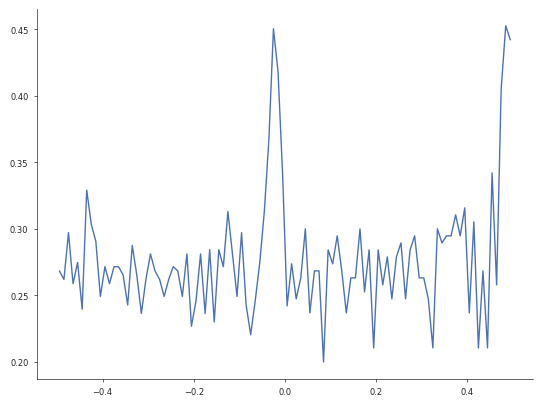

In [ ]:
# Stack PSTHs for right (1, CW) and left (-1, CCW) choice
time_window = meta.times < 0
all_psth = np.concatenate([psth[1.0][:, time_window], psth[-1.0][:, time_window]], axis=1)

# print(all_psth.shape)
# print(meta.times)

plt.plot(meta.times[:100], all_psth[5])
plt.show()

We then apply PCA to reduce the dimensionality of the neural data to **two principal components** and extract the trajectories for left and right choice.

In [ ]:
# Apply PCA to reduce to 2 dimensions
pca = PCA(n_components=2)
trajs = pca.fit_transform(all_psth.T).T

# Extract trajectories for left and right choice
traj_right = trajs[:, :time_window.sum()]
traj_left = trajs[:, time_window.sum():]

# print(traj_right)
# print(trajs.shape)

# print(time_window.sum())

To quantify how the neural representations for the two choices diverge over time, we compute the **Euclidean distance** between their trajectories at each time point.

In [ ]:
euc_dist = np.sqrt(np.sum((traj_left - traj_right) ** 2, axis=0))

We can estimate the **latency** at which the trajectories diverge as the time point at which the Euclidean distance is **70% of it's maximum value**.

In [ ]:
latency_idx = np.argmax(euc_dist > np.max(euc_dist) * 0.7)
latency = meta.times[time_window][latency_idx]

We can visualize both the low-dimensional trajectories and the evolution of their Euclidean distance leading up to the first movement.

Text(0, 0.5, 'Euclidian distance')

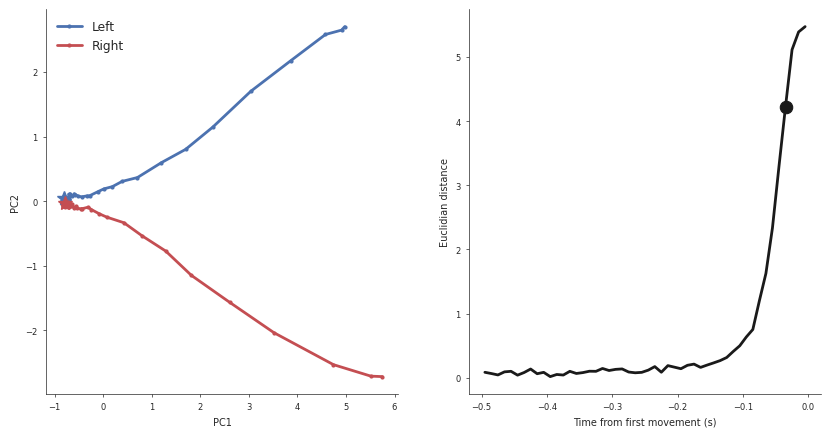

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(10, 5))

# Plot the trajectories
axs[0].plot(traj_left[0, :], traj_left[1, :], color='b', label='Left',  marker='.', lw=2)
axs[0].plot(traj_right[0, :], traj_right[1, :], color='r', label='Right',  marker='.', lw=2)
# Mark the start
axs[0].plot(traj_left[0, 0], traj_left[1, 0], color='b', marker='*', ms=10)
axs[0].plot(traj_right[0, 0], traj_right[1, 0], color='r', marker='*', ms=10)
axs[0].set_xlabel('PC1')
axs[0].set_ylabel('PC2')
axs[0].legend(loc=2, frameon=False)

axs[1].plot(meta.times[time_window], euc_dist, color='k', lw=2)
axs[1].scatter(latency, euc_dist[latency_idx], color='k', s=80)
axs[1].set_xlabel('Time from first movement (s)')
axs[1].set_ylabel('Euclidian distance')

### **Decoding choice from neural activity**

In this section, we will explore whether we can **predict the mouse's choice** (i.e. left or right movement) based on neural activity using **trial-level PSTH data**.

Unlike the previous analyses, which averaged firing rates across trials, we will need to have access to the data on the individual trial level. To facilitate this, we provide three helper functions that return the trial-level data:

* `get_psth_for_insertion`
* `get_psth_for_region`
* `get_psth_for_clusters`


The function **`get_psth_for_insertion`** loads trial-level data for a specified pid. The function returns three objects:

1. A 3D array of shape `n_trials x n_clusters x n_times` containing the PSTH for the specified pid

2. A dataframe describing the clusters for the specified pid

3. A dataframe describing the trials for the specified pid


In [ ]:
# pid = '8ca1a850-26ef-42be-8b28-c2e2d12f06d6'
# psth, clust_df, trials_df = get_psth_for_insertion('8ca1a850-26ef-42be-8b28-c2e2d12f06d6', meta)

# print(psth.shape)
# print(len(clust_df))
# print(len(trials_df))

reg_psth, reg_clust, reg_trials = get_psth_for_region('ORBvl', meta)

psth = reg_psth[1]
clust_df = reg_clust[1]
trials_df = reg_trials[1]



The functions **`get_psth_for_region`** and **`get_psth_for_clusters`** return lists of PSTH arrays, cluster metadata, and trial tables, each corresponding to one probe insertion.

For example, the region VISam has data from 23 separate insertions, so the lists will have length 23.

In [ ]:
psth, clust_reg, trials_reg = get_psth_for_region('HIP', meta)

# print(len(psth))
# print(len(clust_reg))
# print(len(trials_reg))

# print(clust_reg)

We will now demonstrate how to decode the mouse's choice. As choice is a **binary variable (+1, -1)** we will use **logistic regression** on the activity of all clusters from a single insertion.

In [ ]:
# psth, clust_reg, trials_reg = get_psth_for_region('MG', meta)

time_mask = np.bitwise_and(meta.times < 0, meta.times > -0.1)
# print(time_mask)
# print(psth)
X = psth[:, :, time_mask].mean(axis=2)
y = trials_df.choice.values



# Split trials in half into test and training sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=0)

# Fit the logistic regression model
clf = LogisticRegression(random_state=0, max_iter=10000).fit(X_train, y_train)

# Use the test set to assess the model accuracy
choice_predicted = clf.predict(X_test)
n_trial_correct = (y_test == choice_predicted).sum()
print(f'{n_trial_correct}/{len(y_test)} trials correctly predicted')
print(f'Accuracy: {np.round(n_trial_correct/len(y_test), 2) * 100} %')


84/169 trials correctly predicted
Accuracy: 50.0 %


In [ ]:
regions = ['MOp', 'FRP', 'MOB', 'SNr', 'MOs', 'HIP']

overall_choice_predicted = dict()
overall_accuracy = dict()

for i, region in enumerate(regions):

  print(region)

  reg_psth, reg_clust, reg_trials = get_psth_for_region(region, meta)

  sessions = len(reg_psth)

  # preallocate
  choice_predicted = []
  accuracy = []

  for session in range(0,sessions):

    psth = reg_psth[session]
    clust_df = reg_clust[session]
    trials_df = reg_trials[session]


    time_mask = np.bitwise_and(meta.times < 0, meta.times > -0.1)
    X = psth[:, :, time_mask].mean(axis=2)
    y = trials_df.choice.values



    # Split trials in half into test and training sets
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=0)

    # Fit the logistic regression model
    clf = LogisticRegression(random_state=0, max_iter=10000).fit(X_train, y_train)

    # Use the test set to assess the model accuracy


    choice_predicted.append(clf.predict(X_test))
    n_trial_correct_loop = (y_test == choice_predicted[session]).sum()
    accuracy.append(n_trial_correct_loop/len(y_test))

  accuracy_mean = np.mean(accuracy)
  overall_choice_predicted[region] = choice_predicted
  overall_accuracy[region] = accuracy_mean

print(overall_accuracy['FRP'])


# print(f'{n_trial_correct[0]}/{len(y_test)} trials correctly predicted')
# print(f'Accuracy: {np.round(n_trial_correct/len(y_test), 2) * 100} %')


# print(choice_predicted[0])
# print(np.mean(np.asarray(accuracy)))


MOp
FRP
MOB
SNr
MOs
HIP
0.5517993065362876


/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


In [ ]:
# Calculate SD
sd = []
for i, region in enumerate(regions):
  sd.append(np.std(overall_accuracy[region]))

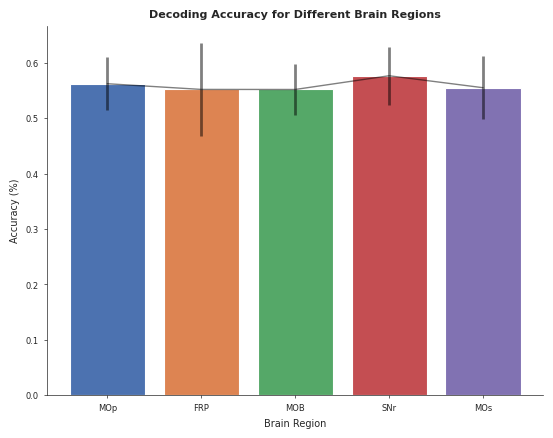

In [ ]:
# # Calculate SD
# sd = []
# for i, region in enumerate(regions):
#   sd.append(np.std(overall_accuracy[region]))



# Plot
plt.bar(range(len(overall_accuracy)), list(overall_accuracy.values()), align='center', color = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B2', '#937860'])
plt.xticks(range(len(overall_accuracy)), list(overall_accuracy.keys()))
plt.errorbar(range(len(overall_accuracy)), list(overall_accuracy.values()), sd, fmt='', color='Black', elinewidth=2,capthick=10,errorevery=1, alpha=0.5, ms=4, capsize = 0)
plt.title('Decoding Accuracy for Different Brain Regions', fontweight="bold")
plt.xlabel('Brain Region')
plt.ylabel('Accuracy (%)')
plt.show()

🟨 **Note**
* In this example, we used a 50/50 train-test split. For a more robust estimate of model performance, you could use leave-one-out cross-validation. This involves training the model on all trials except one, predicting the held-out trial, and repeating for each trial, maximizing the amount of training data used in each iteration.
